# Laboratorio 10 - Obtención gráficas

**Integrantes:**

- Josue Say - 22801
- Flavio Galán - 22386

**Repositorio:**

- [Enlace GitHub](https://github.com/JosueSay/labs-ds/tree/main/lab2)

>**Nota:** Versión 3.12.3 de python

### Librerías

In [992]:
import pandas as pd
import numpy as np
# import pyreadr
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tabulate import tabulate
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from keras.layers import Dropout
import re

### Variables - constantes

In [993]:
DATA_DIR = "../data"
IMAGE_DIR = "./images"
REPORTES = "./reportes"
CACHE = "./cache"

# output files
PRED_STORE = {} 
CONSUMO_CSV = f"{DATA_DIR}/consumo_combustibles.csv"
IMPORT_CSV = f"{DATA_DIR}/importacion_combustibles.csv"
PRECIOS_CSV = f"{DATA_DIR}/precios_diarios.csv"
TARGET_COLUMNS = ["fecha", "regular", "superior", "diesel", "glp"]
SHOW_RESULTS_LAB1 = True # Cambiar para ver las graficas y comparacion de metricas
SHOW_DL_S1 = True # Cambiar para ver las graficas de DL serie combustible regular y metricas
SAVE_IMAGES = True

os.makedirs(IMAGE_DIR, exist_ok=True)

PALETTE = {
    "dominante": "#1B3B5F",   # Azul petróleo (títulos/elementos principales)
    "secundario": "#2E5984",  # Azul medio (líneas principales)
    "mediacion": "#5C7EA3",   # Celeste grisáceo (áreas/etiquetas)
    "neutro": "#B0BEC5",      # Gris metálico (fondo/separadores)
    "acento": "#F28C38"       # Naranja (eventos/picos)
}


SHOW_RESULTS_LAB1 = True
SHOW_DL_S1 = True
SAVE_IMAGES = True
SHOW_TECH_GRAPHS = True

# ========= Estilo global (fondo blanco y look consistente) =========
plt.rcParams.update({
    # Fondos blancos
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    # Textos y títulos en “profundidad” (dominante)
    "axes.titlecolor": PALETTE["dominante"],
    "axes.titleweight": "bold",
    "axes.titlesize": 12,        # título más pequeño
    "axes.labelcolor": PALETTE["dominante"],
    "xtick.color": PALETTE["dominante"],
    "ytick.color": PALETTE["dominante"],
    "text.color":  PALETTE["dominante"],

    # Grilla sutil casi invisible
    "axes.grid": True,
    "grid.color": PALETTE["neutro"],  # #B0BEC5
    "grid.linestyle": "-",
    "grid.alpha": 0.12,

    # Trazos y tipografías
    "lines.linewidth": 2.0,
    "axes.edgecolor": PALETTE["neutro"],
    "axes.linewidth": 0.8,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.frameon": False,
    # Ejes visibles en negrita y solo inferior/izquierdo
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": PALETTE["dominante"],
    "axes.linewidth": 1.2,
})

# Exportación nítida para infografía
EXPORT_KW = dict(dpi=300, bbox_inches="tight")

### Obtención de data

In [994]:
def loadAllData():
    df_consumo = pd.read_csv(CONSUMO_CSV, parse_dates=["fecha"])
    df_importaciones = pd.read_csv(IMPORT_CSV, parse_dates=["fecha"])
    df_precios = pd.read_csv(PRECIOS_CSV, parse_dates=["fecha"])

    df_consumo = df_consumo.set_index("fecha")
    df_importaciones = df_importaciones.set_index("fecha")
    df_precios = df_precios.set_index("fecha")

    print("Datos cargados desde cache CSV.")
    return df_consumo, df_importaciones, df_precios

In [995]:
df_consumo, df_importaciones, df_precios = loadAllData()

Datos cargados desde cache CSV.


### Funciones graficadoras

In [996]:
def plotSeries(df, column, title, save=False, path=None):
    # Datos
    x_dates = df.index.to_pydatetime()
    x = mdates.date2num(x_dates)   # eje X en fechas reales
    y = df[column].values

    # Segmentos para degradado (secundario -> acento)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = LinearSegmentedColormap.from_list(
        "custom", [PALETTE["secundario"], PALETTE["acento"]]
    )
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1))
    lc.set_array(np.linspace(0, 1, len(segments)))
    lc.set_linewidth(2.5)

    # Figura
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")
    ax.add_collection(lc)
    ax.set_xlim(x.min(), x.max()); ax.set_ylim(y.min(), y.max())

    # Título/etiquetas
    ax.set_title(title, fontweight="bold", color=PALETTE["dominante"])
    ax.set_xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
    ax.set_ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])


    # Fechas: formateo y tamaño reducido
    locator = mdates.AutoDateLocator(minticks=4, maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=9)


    plt.tight_layout()
    if save and path:
        plt.savefig(path, **EXPORT_KW)
    plt.show()

In [997]:
def decomposeSeries(series, column, title, save=False, path=None):
    if not SHOW_TECH_GRAPHS:
        return  # ocultar para infografía pública

    s = series[column].copy()
    s.name = ""
    result = seasonal_decompose(s)

    # Figura (fondo blanco heredado de rcParams)
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # --- Trend ---
    axes[0].plot(result.trend, color=PALETTE["mediacion"], linewidth=2.0)
    axes[0].set_title("Tendencia", fontweight="bold", color=PALETTE["dominante"])
    axes[0].set_ylabel("Nivel", fontweight="bold", color=PALETTE["dominante"])
    axes[0].tick_params(axis='x', labelsize=8)
    axes[0].tick_params(axis='y', labelsize=9)

    # --- Seasonal ---
    axes[1].plot(result.seasonal, color=PALETTE["mediacion"], linewidth=2.0)
    axes[1].set_title("Estacionalidad", fontweight="bold", color=PALETTE["dominante"])
    axes[1].set_xlabel("Fecha", fontweight="bold", color=PALETTE["dominante"])
    axes[1].set_ylabel("Amplitud", fontweight="bold", color=PALETTE["dominante"])
    axes[1].tick_params(axis='x', labelsize=8)
    axes[1].tick_params(axis='y', labelsize=9)

    # Formato de fechas consistente
    locator = mdates.AutoDateLocator(minticks=4, maxticks=6)
    axes[1].xaxis.set_major_locator(locator)
    axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    plt.tight_layout()
    if save and path:
        plt.savefig(path, **EXPORT_KW)
    plt.show()

In [998]:
def plotAutocorrelations(series, 
                         title_acf="Autocorrelación (ACF)", 
                         title_pacf="Autocorrelación parcial (PACF)", 
                         figsize=(10,5), 
                         save=False, 
                         path_acf=None, 
                         path_pacf=None):
    if not SHOW_TECH_GRAPHS:
        return  # ocultar para público general

    # --- ACF ---
    fig_acf, ax_acf = plt.subplots(figsize=figsize)
    plot_acf(
        series, ax=ax_acf,
        alpha=0.05,
        use_vlines=True,
        vlines_kwargs={"colors": PALETTE["mediacion"], "linestyle": "-", "linewidths": 2},
        marker="o",
        markersize=5,
        color=PALETTE["mediacion"]
    )

    # Recolorear banda de confianza (PolyCollection)
    for poly in [c for c in ax_acf.collections if hasattr(c, "get_facecolors") and len(c.get_facecolors())>0]:
        poly.set_facecolor(PALETTE["neutro"])
        poly.set_alpha(0.18)
        if hasattr(poly, "set_edgecolor"):
            poly.set_edgecolor("none")

    ax_acf.set_title(title_acf, fontweight="bold", color=PALETTE["dominante"])
    ax_acf.set_xlabel("Lag (días)", fontweight="bold", color=PALETTE["dominante"])
    ax_acf.set_ylabel("Autocorrelación", fontweight="bold", color=PALETTE["dominante"])
    ax_acf.tick_params(axis="x", labelsize=9)
    ax_acf.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    if save and path_acf:
        fig_acf.savefig(path_acf, **EXPORT_KW)
    plt.show()

    # --- PACF ---
    fig_pacf, ax_pacf = plt.subplots(figsize=figsize)
    plot_pacf(
        series, ax=ax_pacf,
        alpha=0.05,
        use_vlines=True,
        vlines_kwargs={"colors": PALETTE["mediacion"], "linestyle": "-", "linewidths": 2},
        marker="o",
        markersize=5,
        color=PALETTE["mediacion"]
    )

    # Recolorear banda de confianza
    for poly in [c for c in ax_pacf.collections if hasattr(c, "get_facecolors") and len(c.get_facecolors())>0]:
        poly.set_facecolor(PALETTE["neutro"])
        poly.set_alpha(0.18)
        if hasattr(poly, "set_edgecolor"):
            poly.set_edgecolor("none")

    ax_pacf.set_title(title_pacf, fontweight="bold", color=PALETTE["dominante"])
    ax_pacf.set_xlabel("Lag (días)", fontweight="bold", color=PALETTE["dominante"])
    ax_pacf.set_ylabel("Autocorrelación parcial", fontweight="bold", color=PALETTE["dominante"])
    ax_pacf.tick_params(axis="x", labelsize=9)
    ax_pacf.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    if save and path_pacf:
        fig_pacf.savefig(path_pacf, **EXPORT_KW)
    plt.show()

In [999]:
def plotResiduals(model, titulo):
    if not SHOW_TECH_GRAPHS:
        return

    residuals = model.resid[1:]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("white")

    # --- Gráfico de residuales ---
    axes[0].plot(residuals, color=PALETTE["mediacion"], linewidth=1.5)
    axes[0].set_title("Residuales", fontweight="bold", color=PALETTE["dominante"])
    axes[0].set_xlabel("Fecha", fontweight="bold", color=PALETTE["dominante"])
    axes[0].set_ylabel("Valor residual", fontweight="bold", color=PALETTE["dominante"])
    axes[0].tick_params(axis='x', labelsize=8)
    axes[0].tick_params(axis='y', labelsize=9)
    axes[0].grid(True, alpha=0.15)

    # --- Gráfico de densidad ---
    axes[1].set_facecolor("white")
    residuals.plot(kind="kde", ax=axes[1], color=PALETTE["acento"], linewidth=2)
    axes[1].set_title("Densidad", fontweight="bold", color=PALETTE["dominante"])
    axes[1].set_xlabel("Valor residual", fontweight="bold", color=PALETTE["dominante"])
    axes[1].set_ylabel("Densidad", fontweight="bold", color=PALETTE["dominante"])
    axes[1].tick_params(axis='x', labelsize=8)
    axes[1].tick_params(axis='y', labelsize=9)
    axes[1].grid(True, alpha=0.15)

    # --- Estilo general ---
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(titulo, fontweight="bold", color=PALETTE["dominante"], fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


### Otra gráficas

In [1027]:
def metrics_to_df(all_metrics: dict):
    """
    all_metrics = {
      "Modelo": {"RMSE": float, "MAE": float},
      ...
    }
    """
    rows = []
    for m, vals in all_metrics.items():
        rows.append({"Modelo": m, "RMSE": vals["RMSE"], "MAE": vals["MAE"]})
    dfm = pd.DataFrame(rows).set_index("Modelo").sort_values("RMSE")
    return dfm
  
def plot_metrics_bars(dfm, metric="RMSE", save=False, path=None):
    best = dfm[metric].idxmin()
    worst = dfm[metric].idxmax()

    colors = []
    for m in dfm.index:
        if m == best:
            colors.append(PALETTE["acento"])      # mejor
        elif m == worst:
            colors.append(PALETTE["neutro"])      # peor
        else:
            colors.append(PALETTE["mediacion"])   # resto

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(dfm.index, dfm[metric].values, color=colors, height=0.6)

    ax.set_title(f"Ranking por {metric}", fontweight="bold", color=PALETTE["dominante"])
    ax.set_xlabel(metric, fontweight="bold", color=PALETTE["dominante"])
    ax.set_ylabel("Modelo", fontweight="bold", color=PALETTE["dominante"])
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Etiquetas de valor al final de cada barra
    for y, v in enumerate(dfm[metric].values):
        ax.text(v, y, f" {v:.2f}", va="center", ha="left", color=PALETTE["dominante"], fontweight="bold")

    # Limpieza
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    if save and path:
        plt.savefig(path, **EXPORT_KW)
    plt.show()

    return best, worst
  
def plot_best_vs_worst(test_index, real_series, preds_all: dict, metrics_all: dict,
                       title="Mejor vs Peor modelo (Periodo de Test)",
                       save=False, path=None):

    def _to_series(pred, index, pad_with="edge"):
        """Ajusta predicciones a la longitud de 'index':
           - Si sobran: toma los ÚLTIMOS N.
           - Si faltan: rellena con el último valor ('edge') o NaN."""
        arr = np.asarray(pred).reshape(-1)
        n = len(index)
        if len(arr) > n:
            arr = arr[-n:]                 # último tramo (alinear al final del test)
        elif len(arr) < n:
            if pad_with == "edge" and len(arr) > 0:
                arr = np.pad(arr, (0, n - len(arr)), mode="edge")
            else:
                arr = np.pad(arr, (0, n - len(arr)), constant_values=np.nan)
        return pd.Series(arr, index=index)

    # Ranking por RMSE
    dfm = metrics_to_df(metrics_all)
    best = dfm["RMSE"].idxmin()
    worst = dfm["RMSE"].idxmax()

    # Real
    y_real = _to_series(real_series, test_index)

    # Preds (si alguna falta, se omite con aviso)
    missing = [k for k in (best, worst) if k not in preds_all]
    if missing:
        print(f"[Aviso] Faltan predicciones para: {missing}. Se graficará lo disponible.")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(y_real.index, y_real.values, label="Real",
            color=PALETTE["secundario"], linewidth=2.2)

    if best in preds_all:
        y_best = _to_series(preds_all[best], test_index)
        ax.plot(y_best.index, y_best.values, label=f"Mejor ({best})",
                color=PALETTE["acento"], linestyle="--", linewidth=2.2)

    if worst in preds_all:
        y_worst = _to_series(preds_all[worst], test_index)
        ax.plot(y_worst.index, y_worst.values, label=f"Peor ({worst})",
                color=PALETTE["neutro"], linestyle="--", linewidth=2.2)

    # Estilo estándar
    ax.set_title(title, fontweight="bold", color=PALETTE["dominante"])
    ax.set_xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
    ax.set_ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=9)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.12)
    ax.legend(frameon=False)
    plt.tight_layout()
    if save and path:
        plt.savefig(path, **EXPORT_KW)
    plt.show()

    return best, worst

### Funciones auxiliares para preparación/ejecución de data

In [1001]:
def splitSeriesByYears(series, train_until="2023", val_year="2024", test_year="2025"):
    
    train = series[:f"{train_until}-12-31"]
    val = series[f"{val_year}-01-01":f"{val_year}-12-31"]
    test = series[f"{test_year}-01-01":]

    return train, val, test

In [1002]:
def getRangeSerie(serie, initial_range, column, get_diff):
    df = serie[initial_range:]
    df = df[column]
    
    if get_diff:
        return df.diff().fillna(0)
    
    return df

In [1003]:
def dickeyFullerTest(series, title="Dickey-Fuller Test"):
    print(f"===== {title} =====\n")
    
    dfTest = adfuller(series, autolag='AIC')
    
    # Resultados principales
    results = {
        "Test Statistic": dfTest[0],
        "p-value": dfTest[1],
        "Lags Used": dfTest[2],
        "N Observations": dfTest[3]
    }
    
    # Valores críticos
    critical_values = dfTest[4]
    
    # Crear tabla
    table_data = []
    for key, value in results.items():
        table_data.append([key, value])
    for key, value in critical_values.items():
        table_data.append([f"Critical Value ({key})", value])
    
    print(tabulate(table_data, headers=["Métrica", "Valor"], tablefmt="fancy_grid"))
    print("\n===== Fin del Test =====")

In [1004]:
def convertToSupervised(series, nLags=1):
    s = np.asarray(series)
    if s.ndim == 1:
        s = s.reshape(-1, 1)
    n = len(s)
    if n <= nLags:
        return np.empty((0, nLags)), np.empty((0,))
    X, y = [], []
    for i in range(n - nLags):
        X.append(s[i:i + nLags, 0])
        y.append(s[i + nLags, 0])
    return np.asarray(X), np.asarray(y)

In [1005]:
def trainARIMAModels(trainData):
    models = [
        ARIMA(trainData, order=(1,1,1)),
        ARIMA(trainData, order=(0,1,1)),
        ARIMA(trainData, order=(1,1,0))
    ]
    return [model.fit() for model in models]

In [1029]:
def runMLPModel(train_scaled, val_scaled, test_scaled, scaler, n_lags=5,
                save=False, path=None, reshape_x_test=False,
                last_level=None, test_level_series=None):
    print("\n[MLP] ====== DEBUG INICIO ======")
    print(f"[MLP] tamaños -> train:{len(train_scaled)}  val:{len(val_scaled)}  test:{len(test_scaled)}")
    print(f"[MLP] n_lags solicitado: {n_lags}")

    # --- lags efectivos ---
    min_needed = min(len(train_scaled)-1, len(val_scaled)-1, len(test_scaled)-1)
    eff_lags = max(1, min(n_lags, min_needed))
    print(f"[MLP] min_needed={min_needed}  -> eff_lags={eff_lags}")

    if min_needed < 1:
        print("[MLP] No se forma ni una ventana.")
        return {"MLP": {"RMSE": np.nan, "MAE": np.nan}}

    # --- supervisado ---
    x_train, y_train = convertToSupervised(train_scaled, eff_lags)
    x_val,   y_val   = convertToSupervised(val_scaled,   eff_lags)

    # x_test con contexto: últimas eff_lags del val + todo el test
    test_ctx = np.vstack([val_scaled[-eff_lags:], test_scaled])  # (eff_lags + len(test), 1)
    X_list, Y_true_list = [], []
    for i in range(len(test_scaled)):            # 1 ventana por mes del test
        X_list.append(test_ctx[i:i+eff_lags, 0]) # entrada: ventana de tamaño eff_lags
        Y_true_list.append(test_scaled[i, 0])    # verdad: diff del mes i del test
    x_test = np.asarray(X_list)
    y_test = np.asarray(Y_true_list)
    print(f"[MLP] x_test con contexto: {x_test.shape}  y_test: {y_test.shape}")
    print(f"[MLP] shapes -> x_train:{x_train.shape} y_train:{y_train.shape} | "
          f"x_val:{x_val.shape} y_val:{y_val.shape} | x_test:{x_test.shape} y_test:{y_test.shape}")

    if x_test.size == 0:
        print(f"[MLP] x_test vacío con eff_lags={eff_lags}.")
        return {"MLP": {"RMSE": np.nan, "MAE": np.nan}}

    # --- modelo (lbfgs, sin shuffle, regularizado) ---
    model = MLPRegressor(
        hidden_layer_sizes=(32,),
        activation='relu',
        solver='lbfgs',
        alpha=1e-2,
        max_iter=5000,
        shuffle=False,
        random_state=1
    )
    model.fit(x_train, y_train)
    print("[MLP] Modelo entrenado (lbfgs, alpha=1e-2, hls=(32,)).")

    # --- Sesgo usando validación ---
    pred_val_scaled = model.predict(x_val)
    pred_val_diff   = scaler.inverse_transform(pred_val_scaled.reshape(-1,1)).ravel()
    true_val_diff   = scaler.inverse_transform(y_val.reshape(-1,1)).ravel()
    bias = np.median(true_val_diff - pred_val_diff)
    print(f"[MLP] bias (mediana val) = {bias:.4f}")

    # --- Test y ajuste ---
    pred_test_scaled = model.predict(x_test if not reshape_x_test else x_test.reshape(1, -1))
    pred_diff = scaler.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()
    true_diff = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

    # Recortar a p2–p98 de train (en escala original)
    train_diff_orig = scaler.inverse_transform(np.asarray(train_scaled).reshape(-1,1)).ravel()
    lo, hi = np.quantile(train_diff_orig, [0.02, 0.98])
    pred_diff_adj = np.clip(pred_diff + bias, lo, hi)

    print(f"[MLP] pred_diff (antes ajuste): {np.round(pred_diff, 2)}")
    print(f"[MLP] pred_diff (bias+clip)   : {np.round(pred_diff_adj, 2)}")
    print(f"[MLP] true_diff               : {np.round(true_diff, 2)}")

    # ===================== Reconstrucción correcta a NIVELES =====================
    if (last_level is not None) and (test_level_series is not None):
        # Serie de niveles con índice de fechas
        if isinstance(test_level_series, pd.Series):
            test_levels = test_level_series.copy()
        else:
            test_levels = pd.Series(np.asarray(test_level_series))

        # Difs reales de TODO el test (escala original)
        test_all_diff = scaler.inverse_transform(np.asarray(test_scaled).reshape(-1, 1)).ravel()
        print(f"[MLP] test_all_diff (len={len(test_all_diff)}): {test_all_diff}")

        y_pred_lvl, y_real_lvl, x_idx = [], [], []
        for i in range(len(pred_diff_adj)):
            # Suma de difs reales ya observadas del test (0..i-1)
            known_sum = test_all_diff[:i].sum()
            # Suma de difs predichas hasta i
            pred_sum  = pred_diff_adj[:i+1].sum()
            lvl_pred  = float(last_level) + known_sum + pred_sum
            idx_real = i  # comparar con el mes i del test

            y_pred_lvl.append(lvl_pred)
            y_real_lvl.append(float(test_levels.iloc[idx_real]))
            x_idx.append(test_levels.index[idx_real] if hasattr(test_levels.index, 'dtype') else idx_real)

            print(f"[MLP] i={i} | known_sum={known_sum:.4f} pred_sum={pred_sum:.4f} "
                  f"-> lvl_pred={lvl_pred:.4f} vs real[{idx_real}]={y_real_lvl[-1]:.4f}")

        y_plot_pred = np.array(y_pred_lvl)
        y_plot_real = np.array(y_real_lvl)
        x_vals = np.array(x_idx)
        xlabel, ylabel = "Fecha", "Precio"
        print(f"[MLP] Ventanas en test: {len(y_plot_real)} (debería ser {len(x_test)})")
    else:
        # Sin niveles: graficar diferencias
        y_plot_real = true_diff
        y_plot_pred = pred_diff_adj
        x_vals = np.arange(len(y_plot_real))
        xlabel, ylabel = "Tiempo", "Diferencia"
        print("[MLP] Graficando en diferencias (no se proporcionó nivel/serie).")

    # --- métricas ---
    rmse = np.sqrt(mean_squared_error(y_plot_real, y_plot_pred))
    mae  = mean_absolute_error(y_plot_real, y_plot_pred)
    print(f"[MLP] RMSE={rmse:.4f}  MAE={mae:.4f}")

    # ===================== Gráfico =====================
    fig, ax = plt.subplots(figsize=(10, 5))
    if len(y_plot_real) >= 2:
        ax.plot(x_vals, y_plot_real, label='Real',        color=PALETTE["secundario"], linewidth=2.2)
        ax.plot(x_vals, y_plot_pred, label='Predicción',  color=PALETTE["acento"], linestyle='--', linewidth=2.2)
    else:
        ax.scatter(x_vals, y_plot_real, label='Real')
        ax.scatter(x_vals, y_plot_pred, label='Predicción')
    ax.set_title(f"Predicción con MLP (lags efectivos={eff_lags})",
                 fontweight="bold", color=PALETTE["dominante"])
    ax.set_xlabel(xlabel, fontweight="bold", color=PALETTE["dominante"])
    ax.set_ylabel(ylabel, fontweight="bold", color=PALETTE["dominante"])
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=9)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save and path:
        plt.savefig(f"{path}/mlp_forecast.png", **EXPORT_KW)
        print(f"[MLP] Figura guardada en: {path}/mlp_forecast.png")
    plt.show()

    # ---- Guardar para uso externo ----
    try:
        PRED_STORE["MLP"] = np.asarray(y_plot_pred, dtype=float)
    except NameError:
        pass

    print("[MLP] ====== DEBUG FIN ======\n")
    return {"MLP": {"RMSE": rmse, "MAE": mae}}

In [1007]:
def runProphetModel(trainData, testData=None, periods=365, save=False, path=None):
    df_train = pd.DataFrame({"ds": trainData.index, "y": list(trainData)})

    model = Prophet()
    model.fit(df_train)

    # Fechas a predecir
    if testData is not None:
        future = pd.DataFrame({
            "ds": pd.date_range(start=trainData.index[0], end=testData.index[-1], freq="D")
        })
    else:
        future = model.make_future_dataframe(periods=periods)

    forecast = model.predict(future)

    # ====== GRÁFICO PRINCIPAL (estándar) ======
    if testData is not None:
        forecast_series = forecast.set_index("ds")["yhat"]
        forecast_trim = forecast_series.loc[testData.index]
        PRED_STORE["Prophet"] = forecast_trim.values

        fig, ax = plt.subplots(figsize=(10, 5))
        # Real (secundario) + Predicción (acento) usando Matplotlib puro
        ax.plot(testData.index, testData.values, label="Real",
                color=PALETTE["secundario"], linewidth=2.2)
        ax.plot(forecast_trim.index, forecast_trim.values, label="Predicción",
                color=PALETTE["acento"], linestyle="--", linewidth=2.2)

        # Títulos/etiquetas en negrita y color de profundidad
        ax.set_title("Predicción con Prophet (Periodo de Test)",
                     fontweight="bold", color=PALETTE["dominante"])
        ax.set_xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
        ax.set_ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])

        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=9)
        ax.legend(frameon=False)
        fig.tight_layout()
        if save and path:
            fig.savefig(f"{path}/prophet_forecast.png", **EXPORT_KW)
        plt.show()

    else:
        # Estilo propio (evitar fig por defecto de Prophet)
        forecast_idx = forecast.set_index("ds")["yhat"]
        futuro_idx = forecast_idx[forecast_idx.index > trainData.index[-1]]

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(trainData.index, trainData.values, label="Histórico",
                color=PALETTE["secundario"], linewidth=2.0)
        if len(futuro_idx) > 0:
            ax.plot(futuro_idx.index, futuro_idx.values, label="Predicción",
                    color=PALETTE["acento"], linestyle="--", linewidth=2.2)

        ax.set_title("Predicción con Prophet",
                     fontweight="bold", color=PALETTE["dominante"])
        ax.set_xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
        ax.set_ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=9)
        ax.legend(frameon=False)
        fig.tight_layout()
        if save and path:
            fig.savefig(f"{path}/prophet_forecast.png", **EXPORT_KW)
        plt.show()

    # ====== Componentes (solo reporte técnico) ======
    if SHOW_TECH_GRAPHS:
        fig2 = model.plot_components(forecast)
        plt.tight_layout()
        if save and path:
            fig2.savefig(f"{path}/prophet_components.png", **EXPORT_KW)
        plt.show()

    # ====== Métricas ======
    results = {}
    if testData is not None:
        forecast_series = forecast.set_index("ds")["yhat"]
        common_dates = testData.index.intersection(forecast_series.index)
        if len(common_dates) > 0:
            y_true = testData.loc[common_dates]
            y_pred = forecast_series.loc[common_dates]
            results["Prophet"] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred)
            }
        else:
            results["Prophet"] = {"RMSE": None, "MAE": None}
    else:
        results["Prophet"] = {"RMSE": None, "MAE": None}

    return forecast, model, results


In [ ]:
def runHoltWintersModel(trainData, testData=None, forecast_steps=None, save=False, path=None):
    # Determinar pasos a predecir
    if testData is not None:
        steps = len(testData)
    else:
        steps = forecast_steps if forecast_steps is not None else 30

    # Ajustar modelo
    model = ExponentialSmoothing(
        trainData,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    )
    fit = model.fit()
    predictions = fit.forecast(steps)

    # Corregir índice del pronóstico
    if testData is not None:
        predictions.index = testData.index
    else:
        last_date = trainData.index[-1]
        predictions.index = pd.date_range(
            start=last_date + pd.Timedelta(days=1),
            periods=steps,
            freq='D'
        )

    try:
        if testData is not None:
            PRED_STORE["Holt-Winters"] = np.asarray(predictions.values, dtype=float)
    except NameError:
        pass

    # ====== GRÁFICO PRINCIPAL (estándar) ======
    plt.figure(figsize=(10, 5))
    if testData is not None:
        # Real (secundario) + Predicción (acento)
        testData.plot(label="Real", color=PALETTE["secundario"], linewidth=2.2)
        predictions.plot(label="Pronóstico", color=PALETTE["acento"], linestyle="--", linewidth=2.2)
        plt.title("Predicción con Holt-Winters (Periodo de Test)", fontweight="bold", color=PALETTE["dominante"])
    else:
        # Entrenamiento y pronóstico futuro
        trainData.plot(label="Histórico", color=PALETTE["secundario"], linewidth=2.0)
        predictions.plot(label="Pronóstico", color=PALETTE["acento"], linestyle="--", linewidth=2.2)
        plt.title("Predicción con Holt-Winters", fontweight="bold", color=PALETTE["dominante"])

    # Ejes y tipografías estándar
    plt.xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
    plt.ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])
    plt.tick_params(axis='x', labelsize=8)
    plt.tick_params(axis='y', labelsize=9)
    plt.legend(frameon=False)
    plt.tight_layout()
    if save and path:
        plt.savefig(f"{path}/holtwinters_forecast.png", **EXPORT_KW)
    plt.show()

    # ====== Métricas ======
    results = {}
    if testData is not None:
        common_dates = testData.index.intersection(predictions.index)
        if len(common_dates) > 0:
            y_true = testData.loc[common_dates]
            y_pred = predictions.loc[common_dates]
            results["Holt-Winters"] = {
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "MAE": mean_absolute_error(y_true, y_pred)
            }
        else:
            results["Holt-Winters"] = {"RMSE": None, "MAE": None}
    else:
        results["Holt-Winters"] = {"RMSE": None, "MAE": None}

    return predictions, fit, results


In [1009]:
def evaluateARIMAModels(models, testData, save=False, path=None):
    newDF = pd.DataFrame({'Real': testData})
    preds_111 = models[0].forecast(len(testData))
    preds_011 = models[1].forecast(len(testData))
    preds_110 = models[2].forecast(len(testData))
    preds_auto = pm.auto_arima(models[0].data.endog, seasonal=False).predict(len(testData))

    newDF = newDF.assign(
        ARIMA_1_1_1=preds_111,
        ARIMA_0_1_1=preds_011,
        ARIMA_1_1_0=preds_110,
        ARIMA_Auto=preds_auto
    )
    newDF.index = testData.index

    line_colors = {
        "Real":        PALETTE["secundario"],
        "ARIMA_1_1_1": PALETTE["mediacion"],
        "ARIMA_0_1_1": PALETTE["dominante"],
        "ARIMA_1_1_0": PALETTE["neutro"],
        "ARIMA_Auto":  PALETTE["acento"]
    }
    line_styles = {"Real": "-", "ARIMA_1_1_1": "--", "ARIMA_0_1_1": "--", "ARIMA_1_1_0": "--", "ARIMA_Auto": "--"}

    fig, ax = plt.subplots(figsize=(10, 5))
    for col in newDF.columns:
        ax.plot(newDF.index, newDF[col].values,
                label=col.replace("_", " "),
                color=line_colors[col],
                linestyle=line_styles[col],
                linewidth=2.2)

    ax.set_title("Predicciones ARIMA vs Real (Periodo de Test)", fontweight="bold", color=PALETTE["dominante"])
    ax.set_xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
    ax.set_ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])
    for lbl in ax.get_xticklabels(): lbl.set_fontweight("bold"); lbl.set_color(PALETTE["dominante"])
    for lbl in ax.get_yticklabels(): lbl.set_fontweight("bold"); lbl.set_color(PALETTE["dominante"])
    ax.tick_params(axis='x', labelsize=8); ax.tick_params(axis='y', labelsize=9)

    ax.grid(True, alpha=0.12)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax.legend(frameon=False)
    fig.tight_layout()
    if save and path:
        plt.savefig(path, **EXPORT_KW)
    plt.show()

    PRED_STORE["ARIMA(1,1,1)"] = np.asarray(preds_111)
    PRED_STORE["ARIMA(0,1,1)"] = np.asarray(preds_011)
    PRED_STORE["ARIMA(1,1,0)"] = np.asarray(preds_110)
    PRED_STORE["ARIMA Auto"]   = np.asarray(preds_auto)

    return {
        "ARIMA(1,1,1)": preds_111,
        "ARIMA(0,1,1)": preds_011,
        "ARIMA(1,1,0)": preds_110,
        "ARIMA Auto": preds_auto
    }

In [1010]:
def convertARIMAPredictionsToMetrics(predictions_dict, true_values):
    metrics = {}
    for model_name, preds in predictions_dict.items():
        rmse = np.sqrt(mean_squared_error(true_values, preds))
        mae = mean_absolute_error(true_values, preds)
        metrics[model_name] = {
            "RMSE": rmse,
            "MAE": mae
        }
    return metrics

In [1011]:
def mergeDisplayMetrics(arima_metrics, arima_values, mlp_metrics, prophet_metrics, hw_metrics, dl_metrics,
                        plot_ranking=True, save=False, path=None):
    metrics = convertARIMAPredictionsToMetrics(arima_metrics, arima_values)
    all_metrics = {
        "MLP": mlp_metrics.get("MLP", mlp_metrics),
        "Prophet": prophet_metrics.get("Prophet", prophet_metrics),
        "Holt-Winters": hw_metrics.get("Holt-Winters", hw_metrics),
        **metrics
    }
    if dl_metrics is not None:
        all_metrics.update(dl_metrics)

    # Tabla en consola + archivo
    table = tabulate([[m, v["RMSE"], v["MAE"]] for m, v in all_metrics.items()],
                     headers=["Modelo", "RMSE", "MAE"], tablefmt="fancy_grid")
    print(table)
    with open("metrics.txt", "w", encoding="utf-8") as f:
        f.write(table)

    # Gráfico de ranking (opcional)
    if plot_ranking:
        dfm = metrics_to_df(all_metrics)
        plot_metrics_bars(dfm, metric="RMSE", save=save,
                          path=(None if path is None else os.path.join(path, "ranking_rmse.png")))

    return all_metrics

### Modelos

In [1012]:
def preprocessLSTM(series):
    """Aplica diferenciación y escalado"""
    diff = series.diff().fillna(0)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(diff.to_frame())
    return diff, scaled, scaler

In [1013]:
def seriesToSupervisedLSTM(scaledSeries, n_lags=5):
    """Convierte serie a formato supervisado para LSTM"""
    x, y = [], []
    for i in range(len(scaledSeries) - n_lags):
        x.append(scaledSeries[i:i+n_lags])
        y.append(scaledSeries[i+n_lags])
    x = np.array(x).reshape(-1, n_lags, 1)
    y = np.array(y)
    return x, y

In [1014]:
def splitSupervisedLSTMByYears(scaledSeries, index, train_until="2023", val_year="2024", test_year="2025", n_lags=5):
    index = pd.to_datetime(index)

    # Crear rangos por año
    train_mask = index <= f"{train_until}-12-31"
    val_mask = (index >= f"{val_year}-01-01") & (index <= f"{val_year}-12-31")
    test_mask = index >= f"{test_year}-01-01"

    # Seleccionar subconjuntos
    train = scaledSeries[train_mask]
    val = scaledSeries[val_mask]
    test = scaledSeries[test_mask]

    # Convertir a formato supervisado
    x_train, y_train = seriesToSupervisedLSTM(train, n_lags)
    x_val, y_val = seriesToSupervisedLSTM(val, n_lags)
    x_test, y_test = seriesToSupervisedLSTM(test, n_lags)

    return x_train, y_train, x_val, y_val, x_test, y_test

In [1015]:
def buildLSTMModel1(n_lags, units=32, optimizer='adam'):
    """Construye el modelo LSTM simple con hiperparámetros"""
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(n_lags, 1)))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [1016]:
def buildLSTMModel2(n_lags, units=64, dropout_rate=0.2, optimizer='adam'):
    """Construye un modelo LSTM más profundo con Dropout"""
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(n_lags, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer=optimizer)
    return model

In [1017]:
def safe_filename(name: str, maxlen: int = 120) -> str:
    """
    Convierte 'name' en un nombre de archivo válido:
    - Reemplaza todo lo que no sea [a-zA-Z0-9_-] por '_'
    - Limita longitud y quita '_' sobrantes al inicio/fin
    """
    name = re.sub(r"[^\w\-]+", "_", name, flags=re.UNICODE)
    return name.strip("_")[:maxlen]

def trainAndEvaluateLSTM(x_train, y_train, x_val, y_val, x_test, y_test,
                         model, scaler, original_series, n_lags,
                         epochs=30, batch_size=32, name_model="LSTM Modelo 1",
                         metrics_dict=None, save=False, path=None):

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=0
    )

    # --- Curva de pérdida (técnico, colores estándar) ---
    if SHOW_TECH_GRAPHS:
        plt.figure(figsize=(10, 4.2))
        plt.plot(history.history['loss'],      label='Train',       color=PALETTE["mediacion"], linewidth=2.0)
        plt.plot(history.history['val_loss'],  label='Validation',  color=PALETTE["acento"],    linewidth=2.0)
        plt.title("LSTM - Pérdida", fontweight="bold", color=PALETTE["dominante"])
        plt.xlabel("Época",  fontweight="bold", color=PALETTE["dominante"])
        plt.ylabel("Pérdida",fontweight="bold", color=PALETTE["dominante"])
        plt.legend()
        plt.tick_params(axis='x', labelsize=8)
        plt.tick_params(axis='y', labelsize=9)
        plt.tight_layout()
        if save and path:
            base = safe_filename(name_model)
            plt.savefig(os.path.join(path, f"lstm_loss_{base}.png"), **EXPORT_KW)
        plt.show()

    # --- Predicción ---
    y_pred_scaled = model.predict(x_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    original = original_series[-(len(y_test_inv) + n_lags):].values
    y_pred_final = y_pred.flatten() + original[n_lags:]
    y_test_final = y_test_inv.flatten() + original[n_lags:]
    PRED_STORE[name_model] = y_pred_final

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
    mae  = mean_absolute_error(y_test_final, y_pred_final)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")

    if metrics_dict is not None:
        metrics_dict[name_model] = {"RMSE": rmse, "MAE": mae}

    # --- Gráfico Real vs Predicción (estándar de color/estilo) ---
    fechas = original_series[-len(y_test_final):].index
    plt.figure(figsize=(10, 5))
    plt.plot(fechas, y_test_final, label="Real",        color=PALETTE["secundario"], linewidth=2.2)
    plt.plot(fechas, y_pred_final, label="Predicción",  color=PALETTE["acento"],    linestyle="--", linewidth=2.2)

    # Títulos/etiquetas en negrita con color de profundidad
    plt.title(name_model, fontweight="bold", color=PALETTE["dominante"])
    plt.xlabel("Fecha",  fontweight="bold", color=PALETTE["dominante"])
    plt.ylabel("Precio", fontweight="bold", color=PALETTE["dominante"])

    # Ticks compactos
    plt.tick_params(axis='x', labelsize=8)
    plt.tick_params(axis='y', labelsize=9)

    plt.legend()
    plt.tight_layout()
    if save and path:
        base = safe_filename(name_model)
        plt.savefig(os.path.join(path, f"{base}.png"), **EXPORT_KW)
    plt.show()

    return rmse, mae

## Modelos LSTM para serie de "Consumos de Diesel"

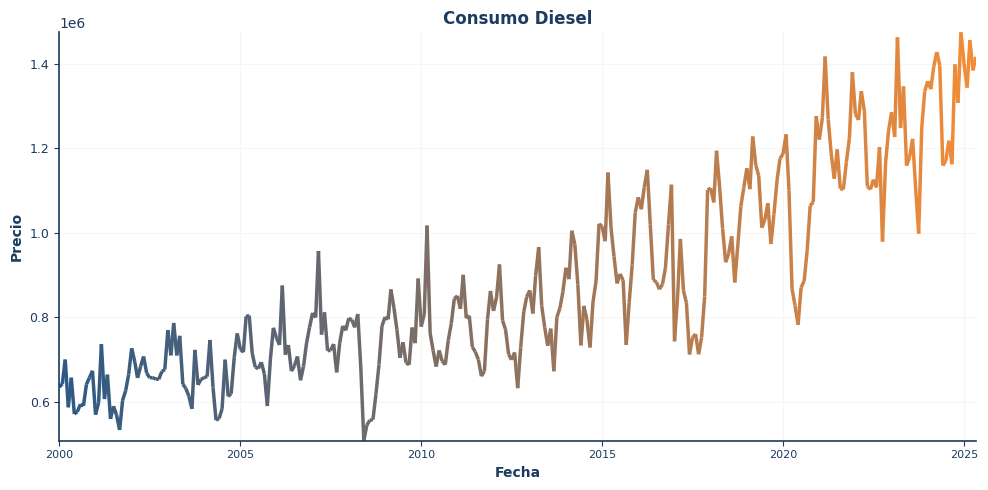

In [1018]:
if SHOW_RESULTS_LAB1:
    plotSeries(df_consumo, column="diesel", title="Consumo Diesel", save=True, path=IMAGE_DIR + "/consumo_diesel.png")

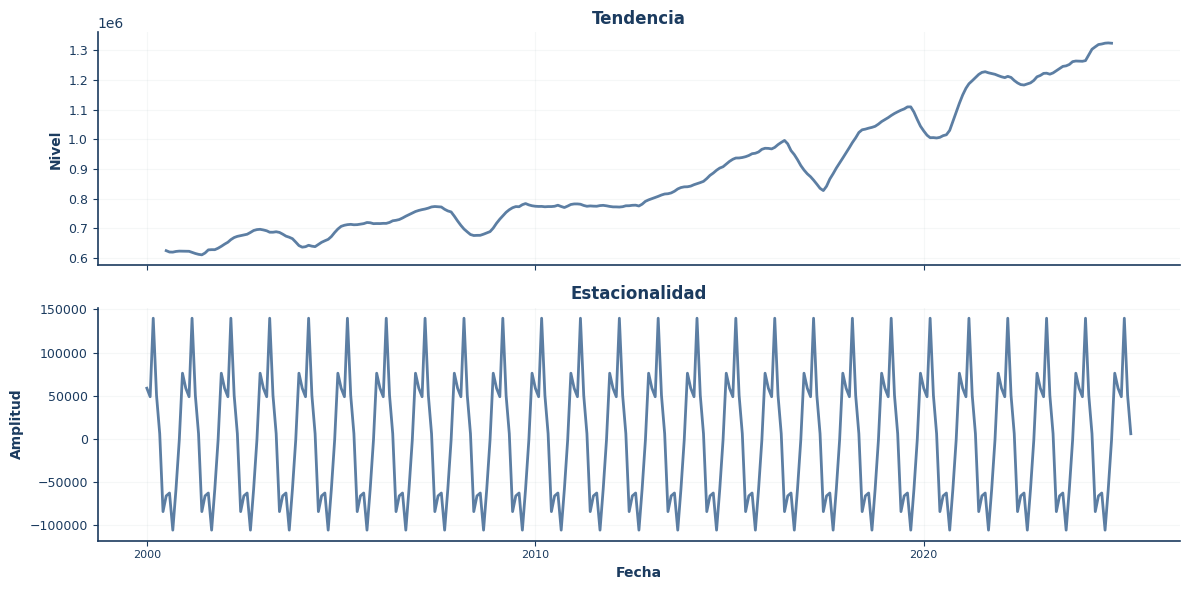

In [1019]:
if SHOW_RESULTS_LAB1 and SHOW_TECH_GRAPHS:
    decomposeSeries(df_consumo, column="diesel", title="Consumo Diesel", save=True, path=IMAGE_DIR + "/descomposition_diesel.png")

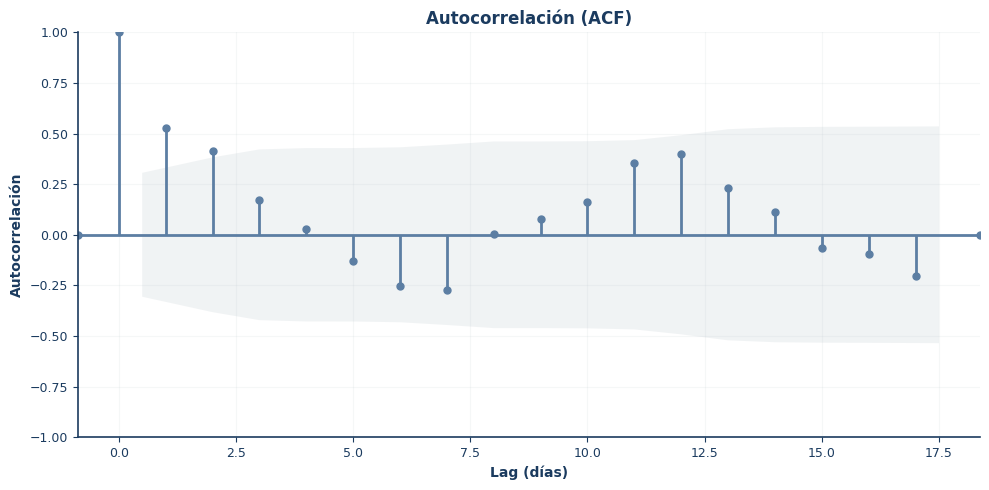

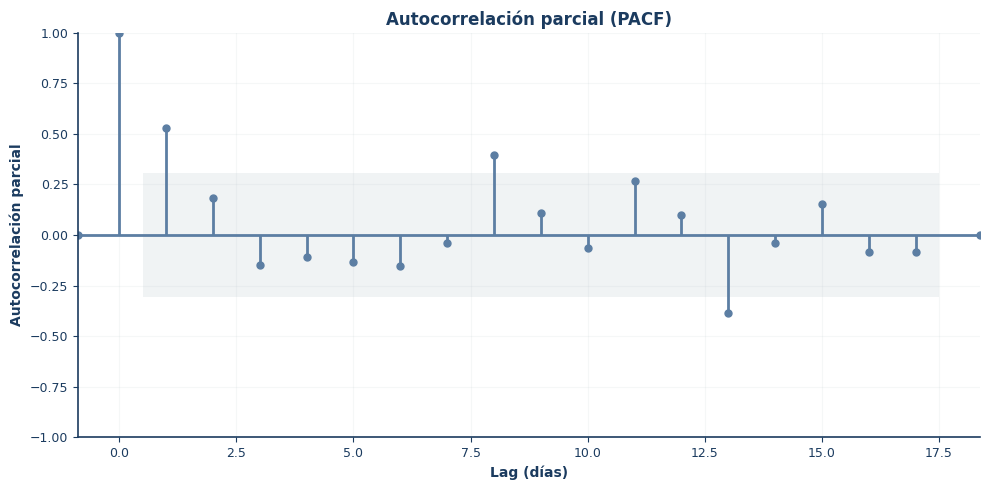

In [1020]:
if SHOW_RESULTS_LAB1 and SHOW_TECH_GRAPHS:
  df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=False)
  plotAutocorrelations(df, save=SAVE_IMAGES,
                      path_acf=IMAGE_DIR + "/acf_diesel.png",
                      path_pacf=IMAGE_DIR + "/pacf_diesel.png")

In [1021]:
if SHOW_RESULTS_LAB1 and SHOW_TECH_GRAPHS:
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=False)
    # Prueba sobre la serie original
    dickeyFullerTest(df, 
                     title="Prueba Dickey-Fuller - Serie Original (Consumo Diesel)")

===== Prueba Dickey-Fuller - Serie Original (Consumo Diesel) =====

╒══════════════════════╤═══════════╕
│ Métrica              │     Valor │
╞══════════════════════╪═══════════╡
│ Test Statistic       │ -0.167383 │
├──────────────────────┼───────────┤
│ p-value              │  0.942299 │
├──────────────────────┼───────────┤
│ Lags Used            │ 10        │
├──────────────────────┼───────────┤
│ N Observations       │ 30        │
├──────────────────────┼───────────┤
│ Critical Value (1%)  │ -3.66992  │
├──────────────────────┼───────────┤
│ Critical Value (5%)  │ -2.96407  │
├──────────────────────┼───────────┤
│ Critical Value (10%) │ -2.62117  │
╘══════════════════════╧═══════════╛

===== Fin del Test =====


In [1022]:
if SHOW_RESULTS_LAB1:
    # Prueba sobre la serie diferenciada
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=True)
    dickeyFullerTest(df, 
                     title="Prueba Dickey-Fuller - Serie Diferenciada (Consumo Diesel)")

===== Prueba Dickey-Fuller - Serie Diferenciada (Consumo Diesel) =====

╒══════════════════════╤══════════════╕
│ Métrica              │        Valor │
╞══════════════════════╪══════════════╡
│ Test Statistic       │ -4.65666     │
├──────────────────────┼──────────────┤
│ p-value              │  0.000101428 │
├──────────────────────┼──────────────┤
│ Lags Used            │ 10           │
├──────────────────────┼──────────────┤
│ N Observations       │ 30           │
├──────────────────────┼──────────────┤
│ Critical Value (1%)  │ -3.66992     │
├──────────────────────┼──────────────┤
│ Critical Value (5%)  │ -2.96407     │
├──────────────────────┼──────────────┤
│ Critical Value (10%) │ -2.62117     │
╘══════════════════════╧══════════════╛

===== Fin del Test =====


### Preparando la serie

In [1023]:
df_rango = df_consumo["diesel"]["2022":].asfreq("D").ffill()
ts_diff, ts_scaled, scaler = preprocessLSTM(df_rango)
x_train, y_train, x_val, y_val, x_test, y_test = splitSupervisedLSTMByYears(
    scaledSeries=ts_scaled,
    index=df_rango.index,
    train_until="2023",
    val_year="2024",
    test_year="2025",
    n_lags=5
)

#### Hiperparámetros

In [1024]:
param_grid = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam"},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam"},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop"},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam"},
]
param_grid_model2 = [
    {"units": 32, "batch_size": 16, "epochs": 30, "optimizer": "adam", "dropout": 0.2},
    {"units": 64, "batch_size": 32, "epochs": 50, "optimizer": "adam", "dropout": 0.3},
    {"units": 64, "batch_size": 16, "epochs": 40, "optimizer": "rmsprop", "dropout": 0.25},
    {"units": 128, "batch_size": 32, "epochs": 60, "optimizer": "adam", "dropout": 0.2},
]

#### Tuneando el modelo


=== Modelo 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


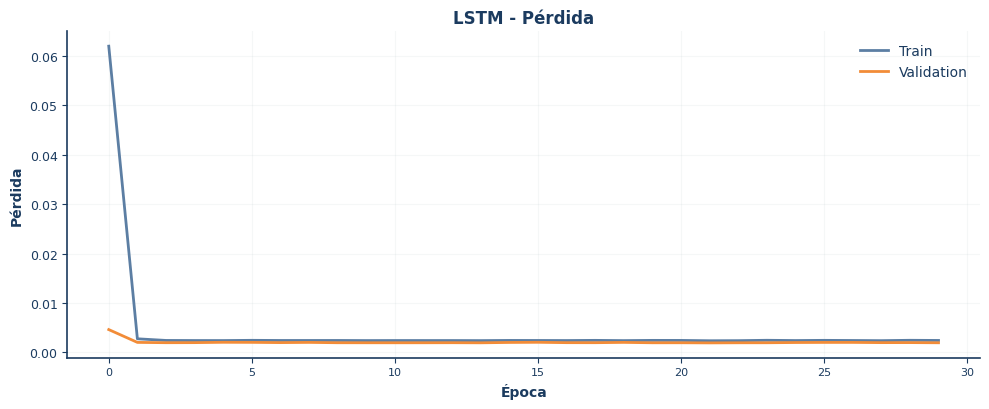

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 14372.2007
MAE:  5893.0252


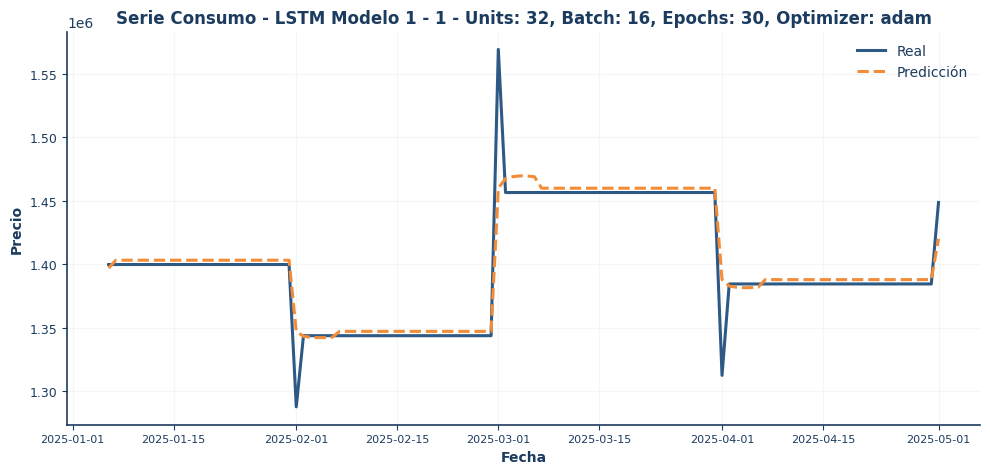


=== Modelo 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


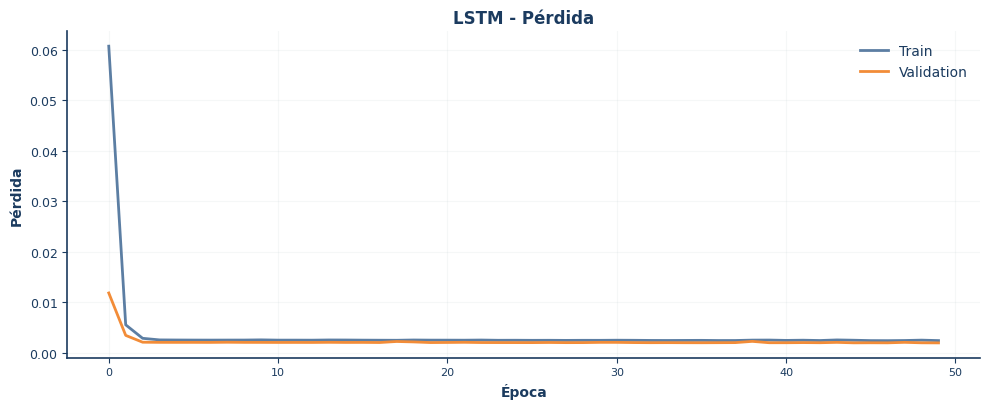

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 14080.2435
MAE:  3958.4421


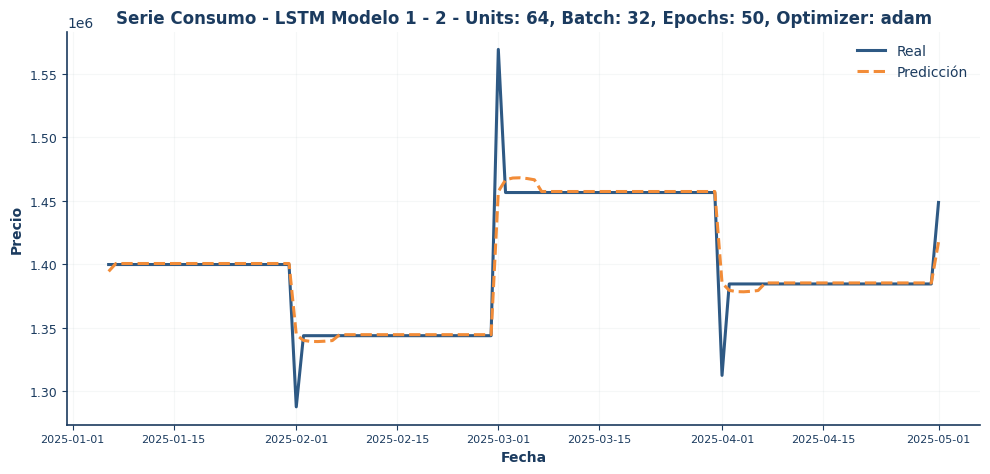


=== Modelo 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


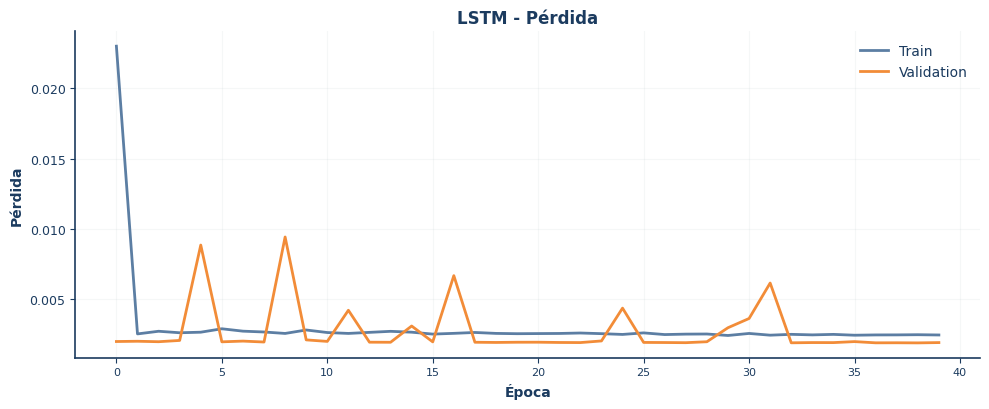

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 14120.9874
MAE:  4915.0271


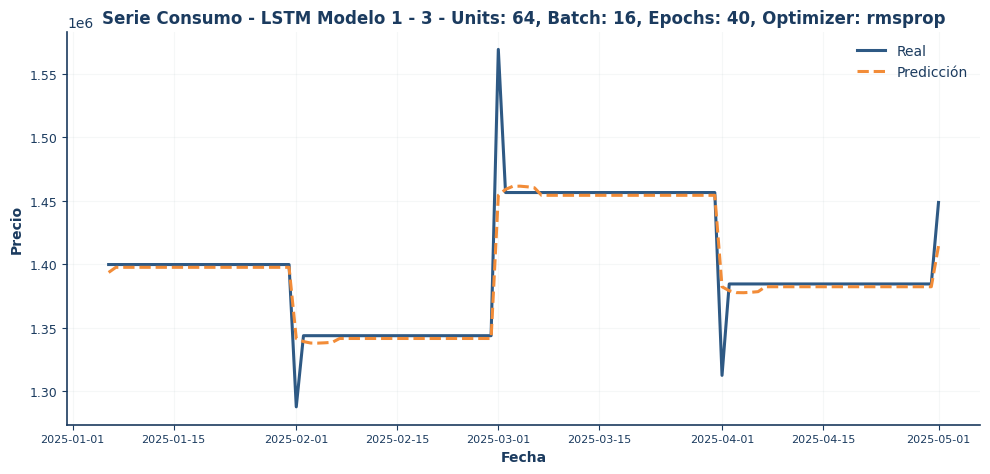


=== Modelo 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


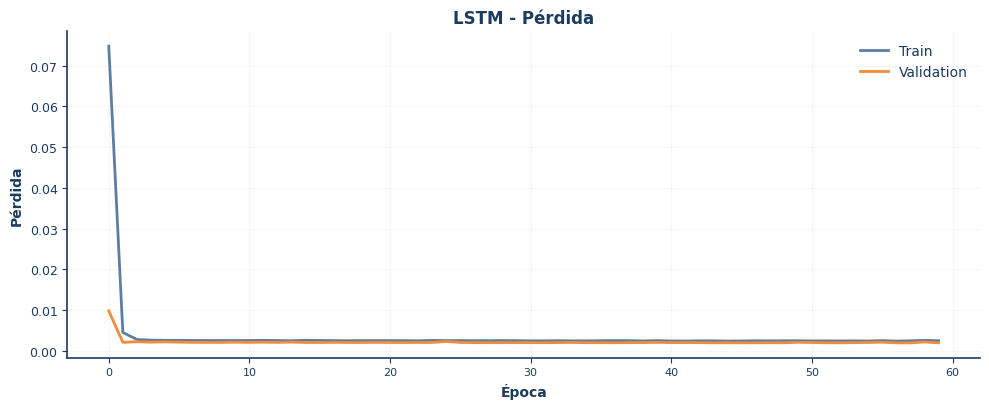

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
RMSE: 14048.1544
MAE:  4456.0122


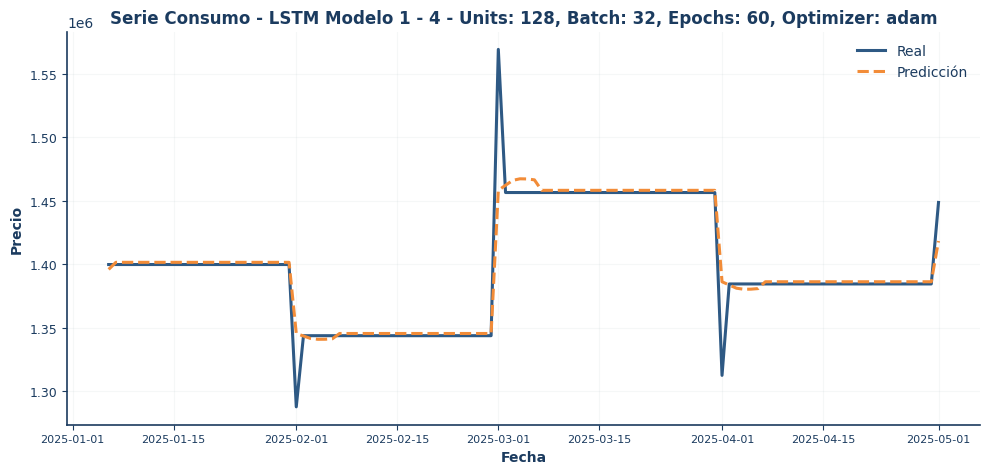


=== Modelo LSTM 2 - Configuración 1 ===
Units: 32, Batch: 16, Epochs: 30, Optimizer: adam, Dropout: 0.2


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


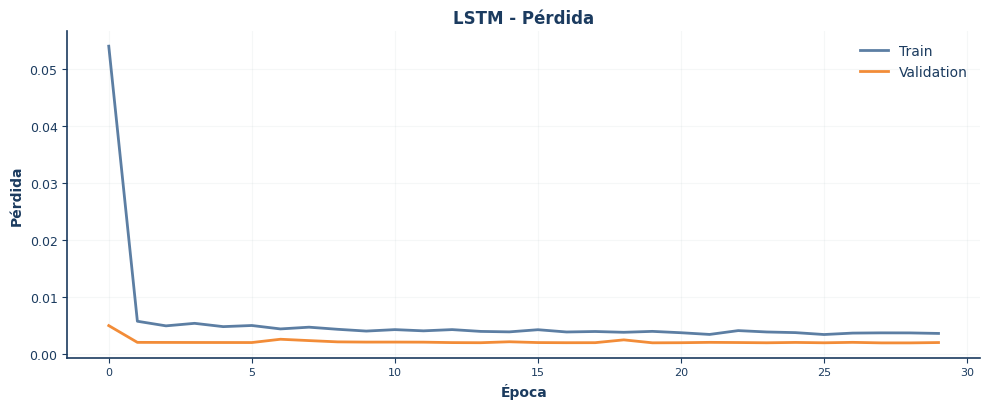

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
RMSE: 14341.9159
MAE:  5889.5776


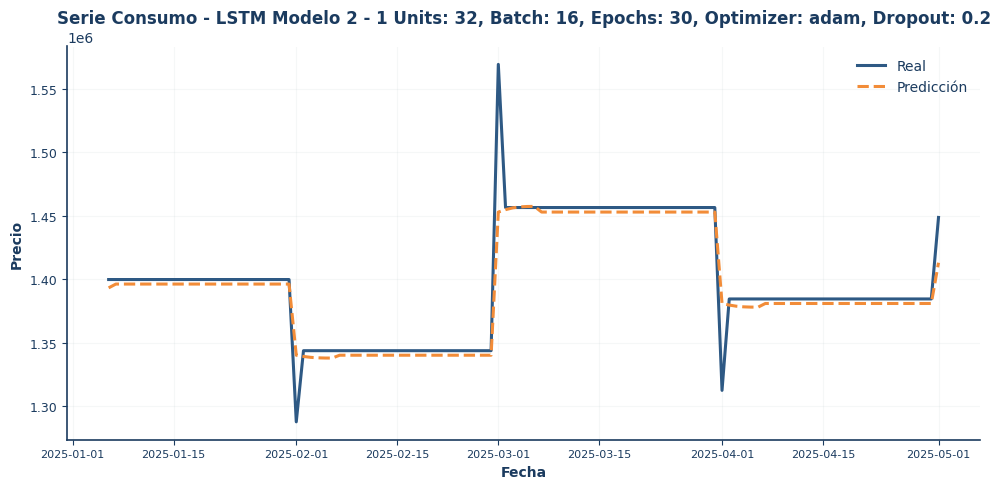


=== Modelo LSTM 2 - Configuración 2 ===
Units: 64, Batch: 32, Epochs: 50, Optimizer: adam, Dropout: 0.3


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


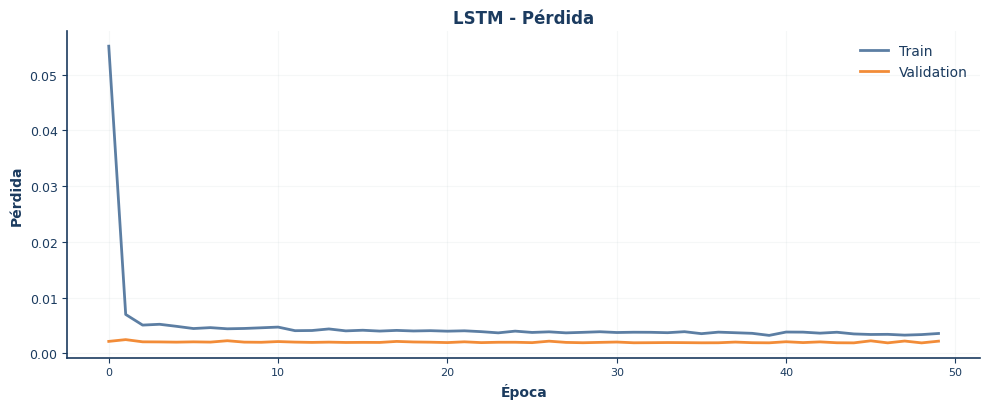

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
RMSE: 16249.9147
MAE:  10437.7088


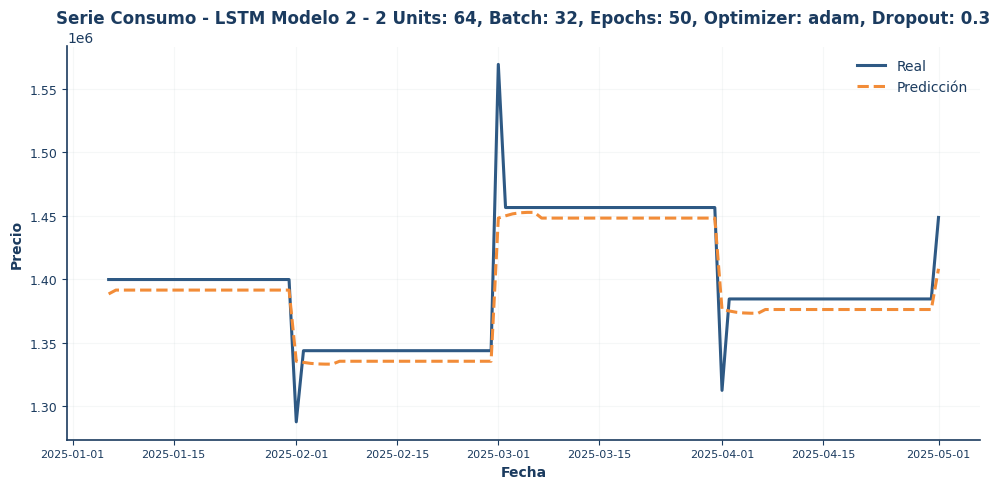


=== Modelo LSTM 2 - Configuración 3 ===
Units: 64, Batch: 16, Epochs: 40, Optimizer: rmsprop, Dropout: 0.25


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


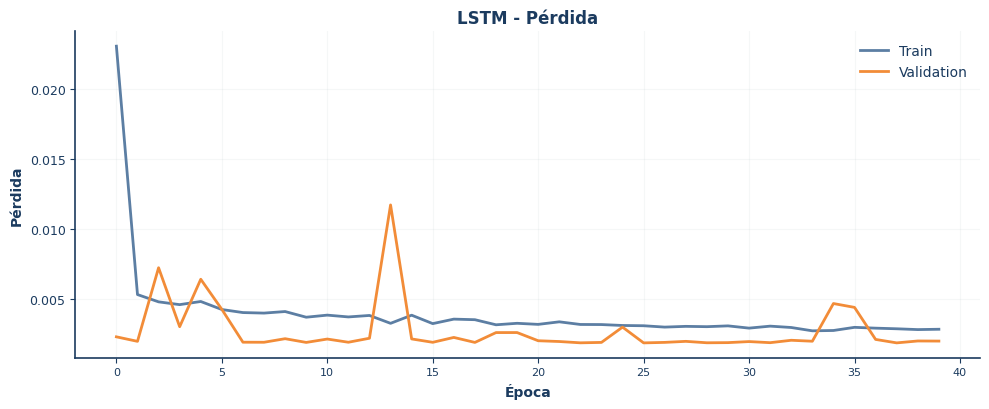

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
RMSE: 14833.8002
MAE:  7464.7813


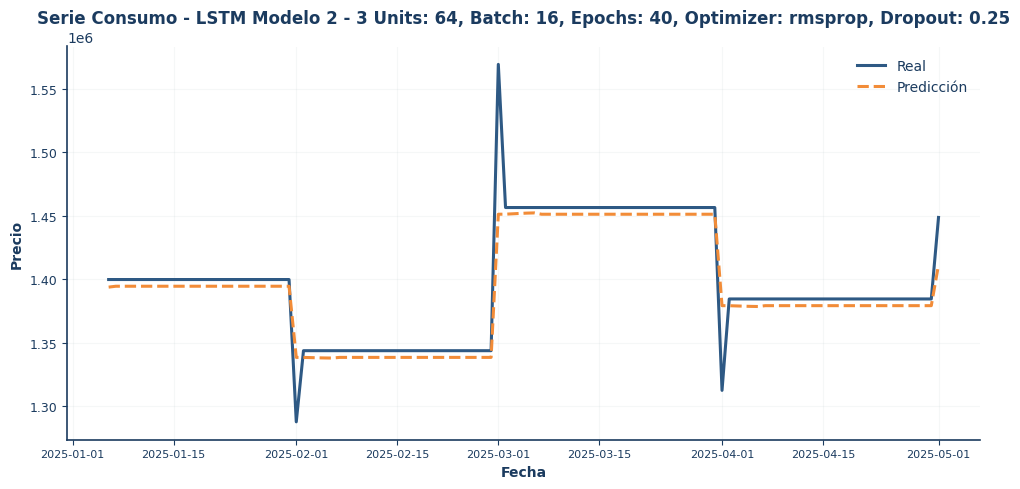


=== Modelo LSTM 2 - Configuración 4 ===
Units: 128, Batch: 32, Epochs: 60, Optimizer: adam, Dropout: 0.2


d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


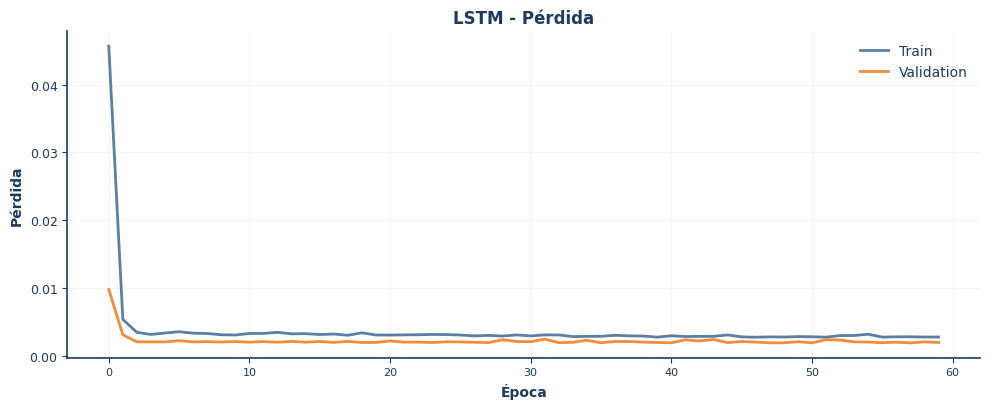

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
RMSE: 14360.5500
MAE:  5952.0083


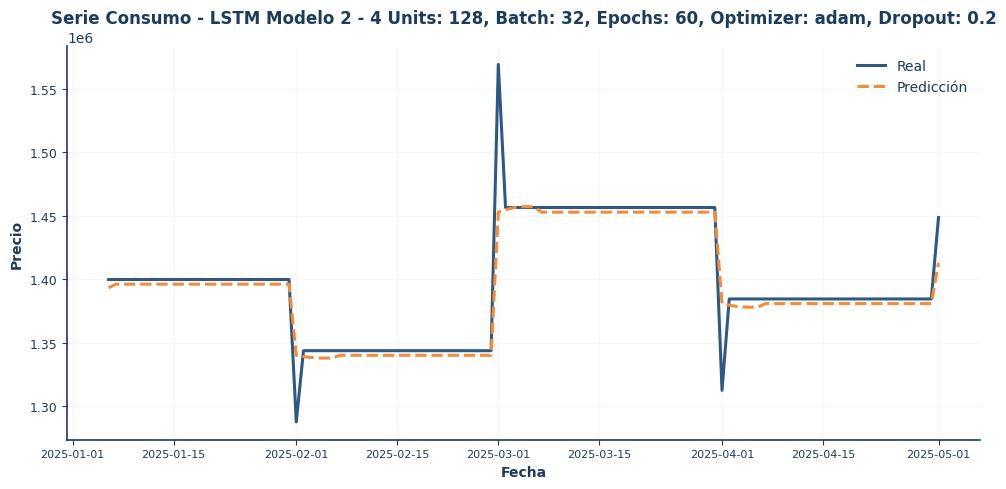

In [1025]:
if SHOW_DL_S1:
    dl_metrics = {}

    for i, params in enumerate(param_grid, 1):
        print(f"\n=== Modelo {i} ===")
        print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}")
        
        model = buildLSTMModel1(n_lags=5, units=params["units"], optimizer=params["optimizer"])
        
        trainAndEvaluateLSTM(
            x_train, y_train,
            x_val, y_val,
            x_test, y_test,
            model,
            scaler,
            df_rango,
            n_lags=5,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            name_model=f"Serie Consumo - LSTM Modelo 1 - {i} - Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, Optimizer: {params['optimizer']}",
            metrics_dict=dl_metrics,
            save=SAVE_IMAGES,
            path=IMAGE_DIR
        )
        
        
    for i, params in enumerate(param_grid_model2, 1):
        print(f"\n=== Modelo LSTM 2 - Configuración {i} ===")
        print(f"Units: {params['units']}, Batch: {params['batch_size']}, Epochs: {params['epochs']}, "
            f"Optimizer: {params['optimizer']}, Dropout: {params['dropout']}")
        
        model = buildLSTMModel2(
            n_lags=5,
            units=params["units"],
            dropout_rate=params["dropout"],
            optimizer=params["optimizer"]
        )
        
        trainAndEvaluateLSTM(
            x_train, y_train,
            x_val, y_val,
            x_test, y_test,
            model,
            scaler,
            df_rango,
            n_lags=5,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            name_model=f"Serie Consumo - LSTM Modelo 2 - {i} Units: {params['units']}, Batch: {params['batch_size']}, "
                    f"Epochs: {params['epochs']}, Optimizer: {params['optimizer']}, Dropout: {params['dropout']}",
            metrics_dict=dl_metrics,
            save=SAVE_IMAGES,
            path=IMAGE_DIR
        )

### Evaluación modelos de lab 1


[MLP] ====== DEBUG INICIO ======
[MLP] tamaños -> train:24  val:12  test:5
[MLP] n_lags solicitado: 2
[MLP] min_needed=4  -> eff_lags=2
[MLP] x_test con contexto: (5, 2)  y_test: (5,)
[MLP] shapes -> x_train:(22, 2) y_train:(22,) | x_val:(10, 2) y_val:(10,) | x_test:(5, 2) y_test:(5,)
[MLP] Modelo entrenado (lbfgs, alpha=1e-2, hls=(32,)).
[MLP] bias (mediana val) = 48537.8715
[MLP] pred_diff (antes ajuste): [-287727.72 -507942.37  145506.22 -221171.12 -306957.35]
[MLP] pred_diff (bias+clip)   : [-219715.61 -219715.61  194044.09 -172633.25 -219715.61]
[MLP] true_diff               : [-74852.68 -56076.88 112811.5  -72044.54  32114.25]
[MLP] test_all_diff (len=5): [-74852.68 -56076.88 112811.5  -72044.54  32114.25]
[MLP] i=0 | known_sum=0.0000 pred_sum=-219715.6072 -> lvl_pred=1254935.4528 vs real[0]=1399798.3800
[MLP] i=1 | known_sum=-74852.6800 pred_sum=-439431.2144 -> lvl_pred=960367.1656 vs real[1]=1343721.5000
[MLP] i=2 | known_sum=-130929.5600 pred_sum=-245387.1218 -> lvl_pred=1098

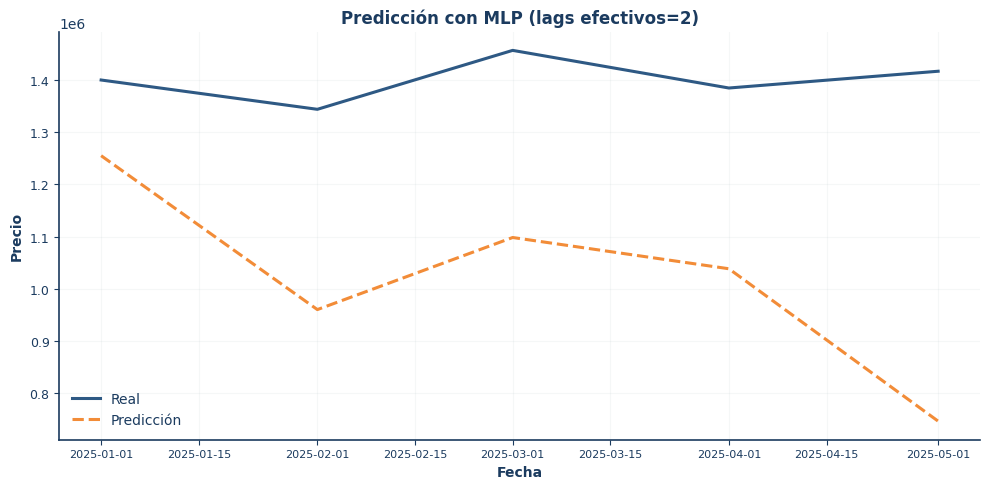

22:52:00 - cmdstanpy - INFO - Chain [1] start processing
22:52:00 - cmdstanpy - INFO - Chain [1] done processing


[MLP] ====== DEBUG FIN ======



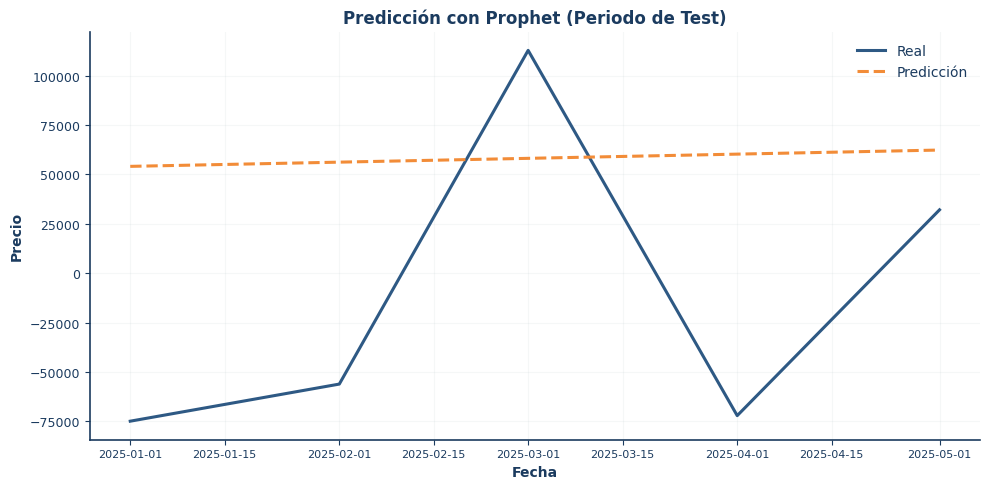

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


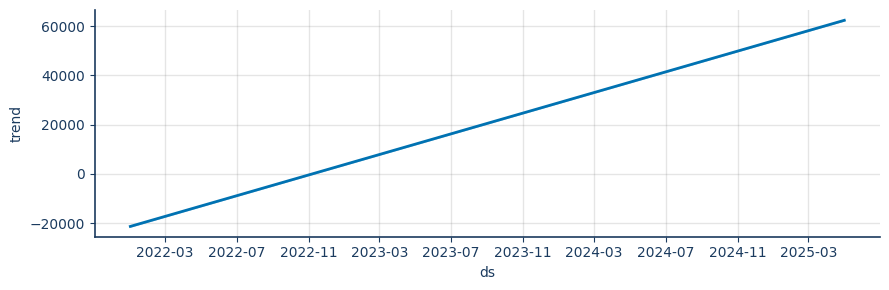

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


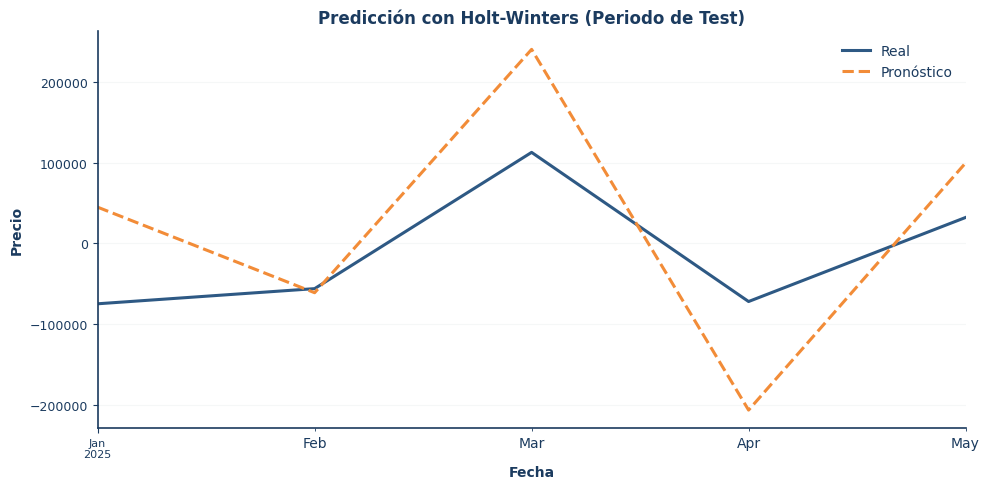

d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\repositorios\UVG\2025\labs-ds\lab10\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py

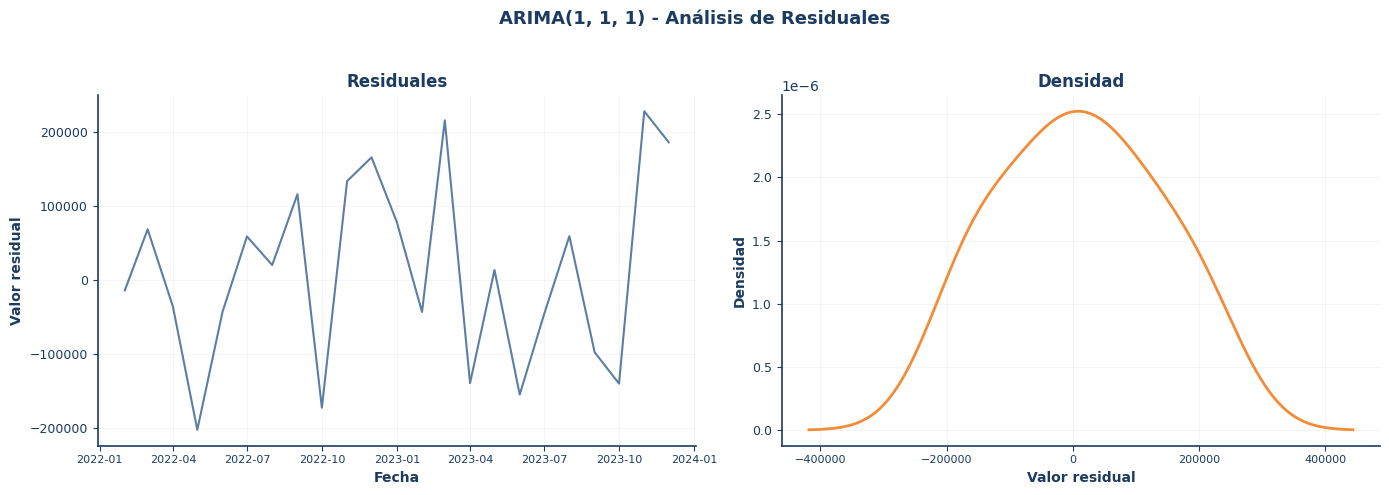

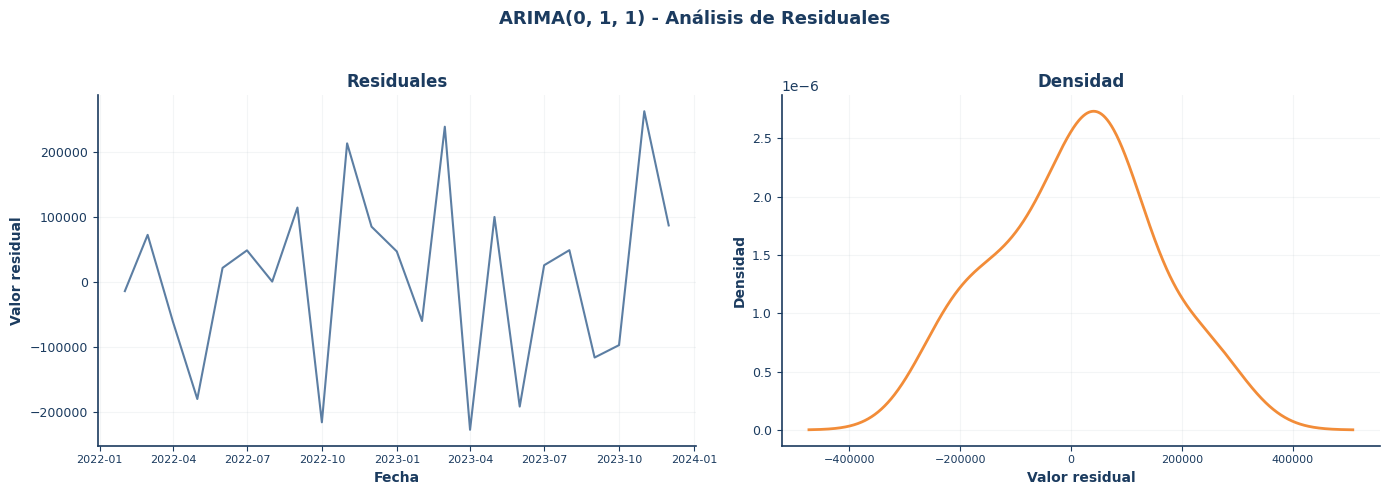

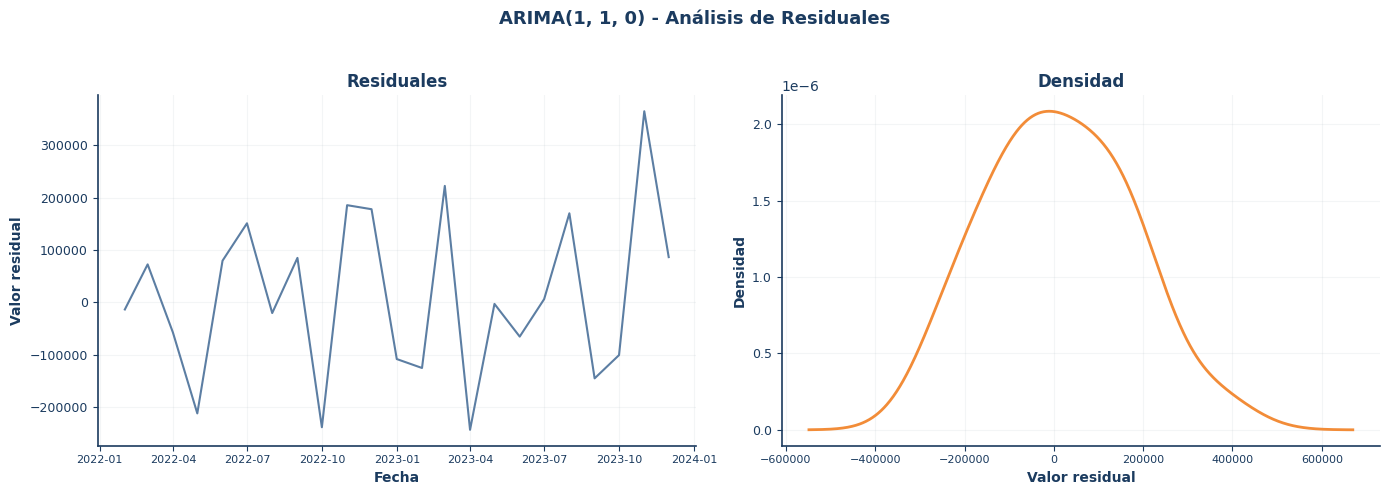

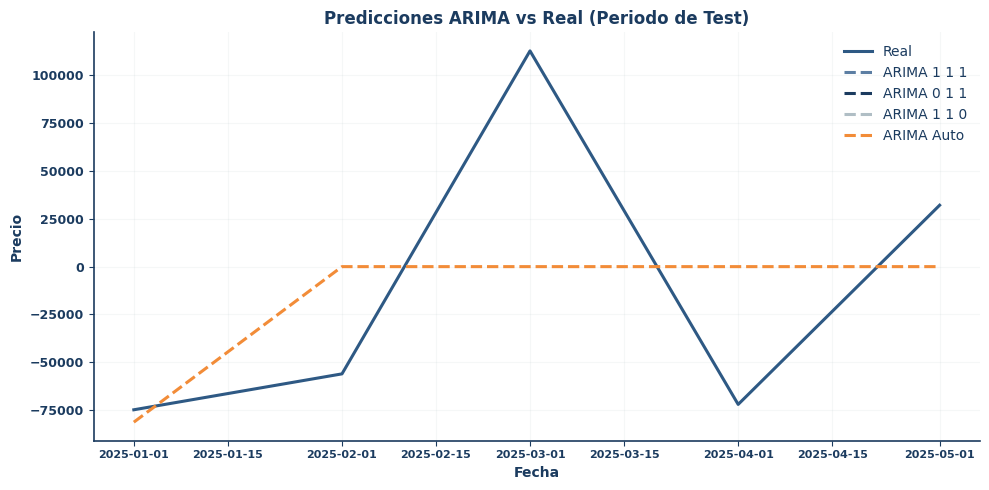

╒═══════════════════════════════════════════════════════════════════════════════════════════════════════╤══════════╤═══════════╕
│ Modelo                                                                                                │     RMSE │       MAE │
╞═══════════════════════════════════════════════════════════════════════════════════════════════════════╪══════════╪═══════════╡
│ MLP                                                                                                   │ 415849   │ 380448    │
├───────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼───────────┤
│ Prophet                                                                                               │ 100661   │  91704.5  │
├───────────────────────────────────────────────────────────────────────────────────────────────────────┼──────────┼───────────┤
│ Holt-Winters                                                                                   

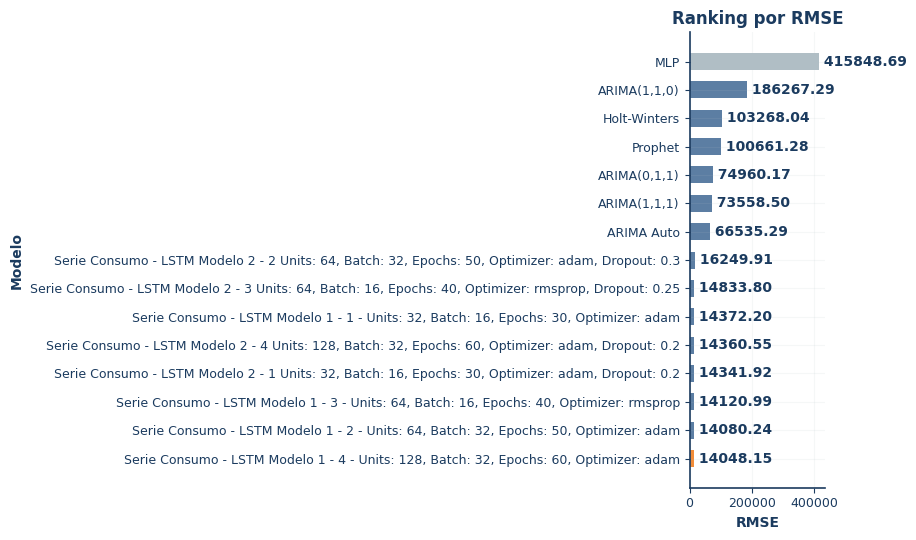

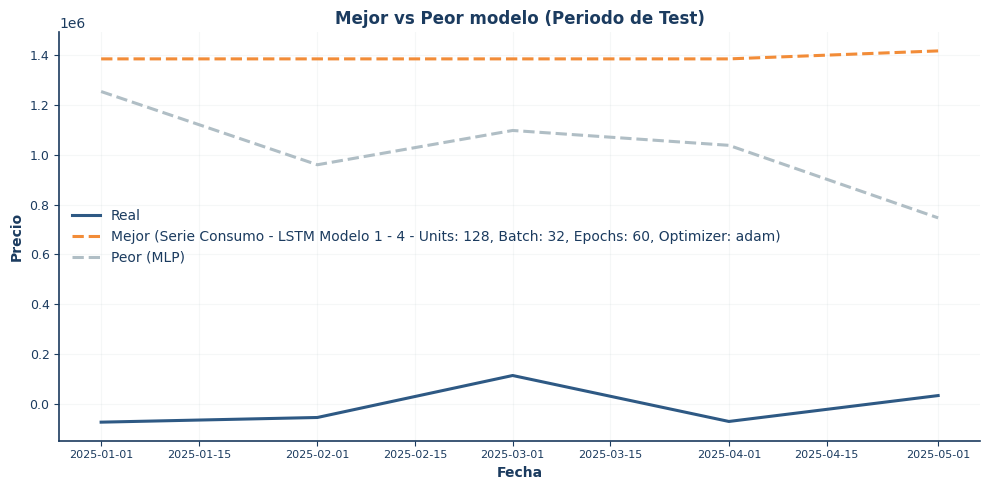

In [1030]:
if SHOW_RESULTS_LAB1:
    df = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=True)
    train_data, val_data, test_data = splitSeriesByYears(df, train_until="2023", val_year="2024", test_year="2025")

    df_level = getRangeSerie(serie=df_consumo, initial_range="2022", column="diesel", get_diff=False)
    train_lvl, val_lvl, test_lvl = splitSeriesByYears(df_level, train_until="2023", val_year="2024", test_year="2025")
    last_level = val_lvl.iloc[-1]          # último nivel observado antes del test
    test_level_series = test_lvl  # conservar índice de fechas



    # Escalado
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train_data.to_frame())
    full_scaled = scaler.transform(df.to_frame())

    train_scaled = full_scaled[:len(train_data)]
    val_scaled   = full_scaled[len(train_data):len(train_data)+len(val_data)]
    test_scaled  = full_scaled[-len(test_data):]

    # Ejecutar modelo MLP
    mlp_metrics = runMLPModel(
        train_scaled, val_scaled, test_scaled, scaler,
        n_lags=2, save=SAVE_IMAGES, path=IMAGE_DIR, reshape_x_test=False,
        last_level=last_level, test_level_series=test_level_series
    )

    # Cantidad de días a predecir (según el tamaño del test real)
    forecast_steps = len(test_data)

    # Modelo Prophet
    forecast, model, prophet_metrics = runProphetModel(
        train_data,
        testData=test_data,
        save=SAVE_IMAGES,
        path=IMAGE_DIR
    )

    # Modelo Holt-Winters
    hw_forecast, hw_model, hw_metrics = runHoltWintersModel(
        trainData=train_data,
        testData=test_data,
        forecast_steps=forecast_steps,
        save=SAVE_IMAGES,
        path=IMAGE_DIR
    )

    # Entrenar modelos ARIMA con el set de entrenamiento
    arima_models = trainARIMAModels(train_data)
    model_orders = [(1, 1, 1), (0, 1, 1), (1, 1, 0)]

    # Analizar residuales de cada modelo
    if SHOW_TECH_GRAPHS:
        for model, order in zip(arima_models, model_orders):
            titulo = f"ARIMA{order} - Análisis de Residuales"
            plotResiduals(model, titulo=titulo)

    # Evaluar modelos con el set de prueba
    arima_metrics = evaluateARIMAModels(
        models=arima_models,
        testData=test_data,
        save=SAVE_IMAGES,
        path=IMAGE_DIR + "/serie_consumos_arima_predictions.png"
    )
    
    all_metrics = mergeDisplayMetrics(arima_metrics, test_data, mlp_metrics, prophet_metrics, hw_metrics, dl_metrics,
                                    plot_ranking=True, save=SAVE_IMAGES, path=IMAGE_DIR)

    # 2) Predicciones por cada modelo que APARECE en la tabla y existe en PRED_STORE
    preds_all = {name: PRED_STORE[name] for name in all_metrics.keys() if name in PRED_STORE}

    # 3) Graficar “Mejor vs Peor”
    _ = plot_best_vs_worst(test_data.index, test_data.values, preds_all, all_metrics,
                        title="Mejor vs Peor modelo (Periodo de Test)",
                        save=SAVE_IMAGES, path=os.path.join(IMAGE_DIR, "best_vs_worst.png"))